In [47]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [48]:
df=sns.load_dataset("diamonds")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [49]:
df=pd.get_dummies(df, columns=["cut", "color", "clarity"], drop_first=True).astype(int)
df.head()

,carat,depth,table,price,x,y,z,cut_Premium,cut_Very Good,cut_Good,...,color_H,color_I,color_J,clarity_VVS1,clarity_VVS2,clarity_VS1,clarity_VS2,clarity_SI1,clarity_SI2,clarity_I1
0,0,61,55,326,3,3,2,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,59,61,326,3,3,2,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,56,65,327,4,4,2,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,0,62,58,334,4,4,2,1,0,0,...,0,1,0,0,0,0,1,0,0,0
4,0,63,58,335,4,4,2,0,0,1,...,0,0,1,0,0,0,0,0,1,0


In [50]:
y=df["price"]
X=df.drop("price", axis=1)

In [51]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.76, random_state=19)

In [52]:
lm=LinearRegression()
model=lm.fit(x_train, y_train)

In [53]:
model.score(x_test, y_test)

0.8676757391870344

In [54]:
model.score(x_train, y_train)
#test and train score are close to each other, so we can say that our model is not overfitting.
#test and train score are not close to each other, so we can say that our model is overfitting.

0.8640803405030832

In [57]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [59]:
df=sns.load_dataset("diamonds")
le = LabelEncoder()
for col in ['cut', 'color', 'clarity']:
    df[col] = le.fit_transform(df[col])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

train_pred = rf_model.predict(X_train)
test_pred = rf_model.predict(X_test)
print("Train R^2 Score:", r2_score(y_train, train_pred))
print("Test R^2 Score:", r2_score(y_test, test_pred))

Train R^2 Score: 0.9781413844261363
Test R^2 Score: 0.948675486427177


In [63]:
rf_model_reg = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15,          
    min_samples_leaf=5,     
    random_state=42
)
rf_model_reg.fit(X_train, y_train)
train_pred_reg = rf_model_reg.predict(X_train)
test_pred_reg = rf_model_reg.predict(X_test)

print("YENİ Train R^2 Score:", r2_score(y_train, train_pred_reg))
print("YENİ Test R^2 Score:", r2_score(y_test, test_pred_reg))

YENİ Train R^2 Score: 0.9625797017711356
YENİ Test R^2 Score: 0.9522053481974638


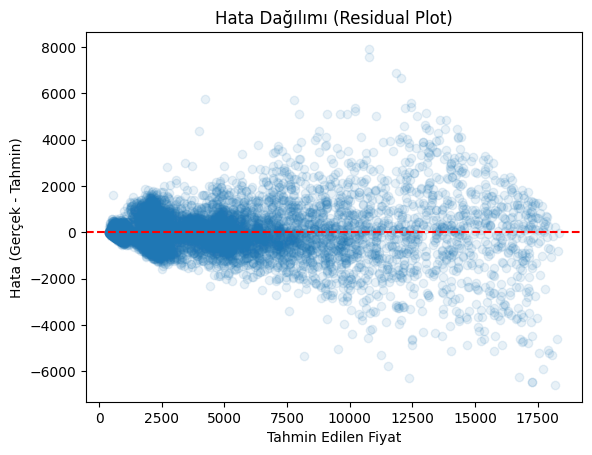

In [64]:
import matplotlib.pyplot as plt

residuals = y_test - test_pred
plt.scatter(test_pred, residuals, alpha=0.1)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Tahmin Edilen Fiyat')
plt.ylabel('Hata (Gerçek - Tahmin)')
plt.title('Hata Dağılımı (Residual Plot)')
plt.show()

In [65]:
import numpy as np
df['volume'] = df['x'] * df['y'] * df['z']
X = df.drop(['price', 'x', 'y', 'z'], axis=1) 

y_log = np.log(y)

X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.20, random_state=42)

rf_final = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, random_state=42)
rf_final.fit(X_train, y_train_log)

train_pred_log = rf_final.predict(X_train)
test_pred_log = rf_final.predict(X_test)

print("Final Train R^2 (Log):", r2_score(y_train_log, train_pred_log))
print("Final Test R^2 (Log):", r2_score(y_test_log, test_pred_log))

Final Train R^2 (Log): 0.9931147004479717
Final Test R^2 (Log): 0.9894852531917347
